# ![UFC Logo](https://sdmntprwestus.oaiusercontent.com/files/00000000-acf8-6230-b3d5-2d7aa9d62a54/raw?se=2025-04-06T21%3A47%3A38Z&sp=r&sv=2024-08-04&sr=b&scid=a51450d0-60c9-58f3-8c21-92f50cd6125f&skoid=e872f19f-7b7f-4feb-9998-20052dec61d6&sktid=a48cca56-e6da-484e-a814-9c849652bcb3&skt=2025-04-06T10%3A57%3A11Z&ske=2025-04-07T10%3A57%3A11Z&sks=b&skv=2024-08-04&sig=rnAWJNJAhP2pDb0ngRnUzldeIetik0ZK%2BTDj4%2B4fHEY%3D)

# UFC Fight Data Analysis

This notebook combines web scraping and data wrangling to analyze UFC fight statistics. It follows these key steps:

1. **Web Scraping**: Extract UFC fight data from ufcstats.com using Scrapy
2. **Data Wrangling**: Clean and transform the data for analysis
3. **Exploratory Data Analysis**: Visualize and analyze fight patterns and statistics



## 1. Setup

First, let's import the necessary libraries and data paths for the project.

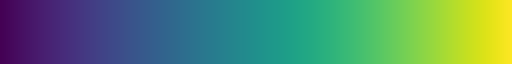

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scrapy
from scrapy.crawler import CrawlerProcess
import os
from datetime import datetime

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
sns.color_palette('viridis', as_cmap=True)

In [2]:
# Define the base directory for data
base_dir = os.path.dirname(os.path.abspath('.'))  # Get project root directory
data_dir = os.path.join(base_dir, "Data")
scraped_data_dir = os.path.join(data_dir, "Scraped_Data")
wrangled_data_dir = os.path.join(data_dir, "wrangled_Data")

# Create directories if they don't exist
os.makedirs(data_dir, exist_ok=True)
os.makedirs(scraped_data_dir, exist_ok=True)
os.makedirs(wrangled_data_dir, exist_ok=True)

# Define paths to save the CSV files
scrapped_event_links_path = os.path.join(scraped_data_dir, "scrapped_event_links.csv")
scrapped_fights_path = os.path.join(scraped_data_dir, "scrapped_fight_details.csv")

wrangled_event_links_path = os.path.join(wrangled_data_dir, "wrangled_event_links.csv")
wrangled_fights_path = os.path.join(wrangled_data_dir, "wrangled_fight_details.csv")

## 2. Web Scraping UFC Fight Data

I have used Scrapy to scrape fight data from ufcstats.com. The spider will:
1. Crawl UFC event pages
2. Extract event links
3. Follow those links to extract fight details
4. Store the data in structured format

In [3]:
# Initialize lists to store UFC fights data
pages = 1  # Set the number of pages to scrape (increase for more data)
event_links = []  # List to store event links separately
fights = []  # List to store fight details

### Define the Scrapy Spider

The `UfcSpider` class handles the web scraping process with three main methods:
1. `start_requests`: Initiates scraping from the main events page
2. `parse_events`: Extracts event details and fight links
3. `parse_fights`: Collects detailed fight statistics

In [4]:
# Define a Scrapy Spider to scrape UFC fight data
class UfcSpider(scrapy.Spider):
    name = "ufc_spider"

    def start_requests(self):
        """Start by sending requests to the UFC statistics events pages."""
        for page in range(1, pages + 1):
            url = f"http://ufcstats.com/statistics/events/completed?page={page}"
            yield scrapy.Request(url=url, callback=self.parse_main)

    def parse_main(self, response):
        """Extract event links from the page and follow them."""
        event_links_on_page = response.css("a.b-link.b-link_style_black::attr(href)").extract()

        for event_link in event_links_on_page:
            event_links.append({"event_link": event_link})
            yield response.follow(url=event_link, callback=self.parse_events)

    def parse_events(self, response):
        """Extract fight links, date, and location from the event page."""
        fight_links = response.css("a.b-flag.b-flag_style_green::attr(href)").extract()
        date = response.css("li.b-list__box-list-item:nth-child(1)::text").extract()[1]
        location = response.css("li.b-list__box-list-item:nth-child(2)::text").extract()[1]

        for fight_link in fight_links:
            yield response.follow(
                url=fight_link,
                callback=self.parse_fights,
                meta={"date": date, "location": location},
            )

    def parse_fights(self, response):
        """Extract fight details such as fighters, results, and statistics."""
        # Extract metadata
        date = response.meta["date"]
        location = response.meta["location"]

        # Extract fighter details
        fighter_details = self._extract_fighter_details(response)
        
        # Extract fight information
        fight_info = self._extract_fight_info(response)
        
        # Extract overall statistics
        overall_stats = self._extract_overall_stats(response)
        
        # Extract significant strike statistics
        sig_strike_stats = self._extract_sig_strike_stats(response)
        
        # Extract round-by-round statistics
        round_stats = self._extract_round_stats(response)
        
        # Combine all fight data into a single dictionary
        fight_data = {
            "fight_link": response.url,
            "date": date,
            "location": location,
            **fighter_details,
            **fight_info,
            **overall_stats,
            **sig_strike_stats,
            **round_stats
        }
        
        # Add the fight data to our list
        fights.append(fight_data)

    def _extract_fighter_details(self, response):
        """Extract fighter names, nicknames, and win/loss status."""
        fighter_details = response.css("div.b-fight-details__person")
        win_loss_1, win_loss_2 = fighter_details.css("i.b-fight-details__person-status::text").extract()[0:2]
        name_1, name_2 = fighter_details.css("h3 > a::text").extract()[0:2]
        stage_name_1, stage_name_2 = fighter_details.css("p.b-fight-details__person-title::text").extract()[0:2]
        
        return {
            "name_1": name_1,
            "name_2": name_2,
            "stage_name_1": stage_name_1,
            "stage_name_2": stage_name_2,
            "win_loss_1": win_loss_1,
            "win_loss_2": win_loss_2,
        }

    def _extract_fight_info(self, response):
        """Extract general fight information (method, round, time, etc.)."""
        fight_details = response.css("div.b-fight-details__content")
        
        method = fight_details.css(
            "p:nth-child(1) > i.b-fight-details__text-item_first > i:nth-child(2)::text"
        ).get()
        round_num = fight_details.css("p:nth-child(1) > i:nth-child(2)::text").extract()[1]
        time = fight_details.css("p:nth-child(1) > i:nth-child(3)::text").extract()[1]
        time_format = fight_details.css("p:nth-child(1) > i:nth-child(4)::text").extract()[1]
        referee = fight_details.css("p:nth-child(1) > i:nth-child(5) > span::text").get()
        details = fight_details.css("p:nth-child(2)::text").extract()[1].strip()
        
        return {
            "method": method,
            "round": round_num,
            "time": time,
            "time_format": time_format,
            "referee": referee,
            "details": details,
        }

    def _extract_overall_stats(self, response):
        """Extract general fight statistics (knockdowns, takedowns, etc.)."""
        stats_table = response.css("body > section > div > div > section:nth-child(4) > table > tbody")
        
        kd_1, kd_2 = stats_table.css("td:nth-child(2) p::text").extract()[0:2]
        total_str_1, total_str_2 = stats_table.css("td:nth-child(5) p::text").extract()[0:2]
        td_1, td_2 = stats_table.css("td:nth-child(6) p::text").extract()[0:2]
        sub_1, sub_2 = stats_table.css("td:nth-child(8) p::text").extract()[0:2]
        rev_1, rev_2 = stats_table.css("td:nth-child(9) p::text").extract()[0:2]
        ctrl_1, ctrl_2 = stats_table.css("td:nth-child(10) p::text").extract()[0:2]
        
        return {
            "kd_1": kd_1, "kd_2": kd_2,
            "total_str_1": total_str_1, "total_str_2": total_str_2,
            "td_1": td_1, "td_2": td_2,
            "sub_1": sub_1, "sub_2": sub_2,
            "rev_1": rev_1, "rev_2": rev_2,
            "ctrl_1": ctrl_1, "ctrl_2": ctrl_2,
        }

    def _extract_sig_strike_stats(self, response):
        """Extract significant strike statistics."""
        sig_str_table = response.css("body > section > div > div > table > tbody")
            
        sig_str_1, sig_str_2 = sig_str_table.css("td:nth-child(2) p::text").extract()[0:2]
        sig_str_head_1, sig_str_head_2 = sig_str_table.css("td:nth-child(4) p::text").extract()[0:2]
        sig_str_body_1, sig_str_body_2 = sig_str_table.css("td:nth-child(5) p::text").extract()[0:2]
        sig_str_legs_1, sig_str_legs_2 = sig_str_table.css("td:nth-child(6) p::text").extract()[0:2]
        sig_str_dist_1, sig_str_dist_2 = sig_str_table.css("td:nth-child(7) p::text").extract()[0:2]
        sig_str_clinch_1, sig_str_clinch_2 = sig_str_table.css("td:nth-child(8) p::text").extract()[0:2]
        sig_str_ground_1, sig_str_ground_2 = sig_str_table.css("td:nth-child(9) p::text").extract()[0:2]
        
        return {
            "sig_str_1": sig_str_1, "sig_str_2": sig_str_2,
            "sig_str_head_1": sig_str_head_1, "sig_str_head_2": sig_str_head_2,
            "sig_str_body_1": sig_str_body_1, "sig_str_body_2": sig_str_body_2,
            "sig_str_legs_1": sig_str_legs_1, "sig_str_legs_2": sig_str_legs_2,
            "sig_str_dist_1": sig_str_dist_1, "sig_str_dist_2": sig_str_dist_2,
            "sig_str_clinch_1": sig_str_clinch_1, "sig_str_clinch_2": sig_str_clinch_2,
            "sig_str_ground_1": sig_str_ground_1, "sig_str_ground_2": sig_str_ground_2,
        }

    def _extract_round_stats(self, response):
        """Extract round-by-round statistics."""
        all_round_stats = {}

        # Select all tbody elements from the per-round sig strike table
        round_tables = response.css("table.b-fight-details__table.js-fight-table > tbody")[1:]

        for round_num in range(1, 6):  # Maximum 5 rounds
            if round_num <= len(round_tables):
                round_table = round_tables[round_num - 1]
                round_stats = self._extract_single_round_stats(round_table)
            else:
                round_stats = self._get_empty_round_stats()

            prefixed_round_stats = {
                f"r{round_num}_{key}": value for key, value in round_stats.items()
            }

            all_round_stats.update(prefixed_round_stats)

        return all_round_stats


    def _extract_single_round_stats(self, response, round_number):
        """Extract statistics for a specific round."""
        # Define the tbody selector for this round
        round_table = response.css(
            f"body > section > div > div > section:nth-child(8) > table > tbody:nth-child({2 + round_number*2})"
        )
        
        if not round_table:
            # Return null for all values if this round doesn't exist
            return self._get_empty_round_stats()
        
        try:
            # Extract stats for each metric
            stats = {}
            
            # Significant strikes
            sig_str = round_table.css("td:nth-child(2) p::text").extract()
            stats["sig_str_1"] = sig_str[0] if len(sig_str) > 0 else "null"
            stats["sig_str_2"] = sig_str[1] if len(sig_str) > 1 else "null"
            
            # Significant strike percentage
            sig_str_pct = round_table.css("td:nth-child(3) p::text").extract()
            stats["sig_str_pct_1"] = sig_str_pct[0] if len(sig_str_pct) > 0 else "null"
            stats["sig_str_pct_2"] = sig_str_pct[1] if len(sig_str_pct) > 1 else "null"
            
            # Head strikes
            head = round_table.css("td:nth-child(4) p::text").extract()
            stats["head_1"] = head[0] if len(head) > 0 else "null"
            stats["head_2"] = head[1] if len(head) > 1 else "null"
            
            # Body strikes
            body = round_table.css("td:nth-child(5) p::text").extract()
            stats["body_1"] = body[0] if len(body) > 0 else "null"
            stats["body_2"] = body[1] if len(body) > 1 else "null"
            
            # Leg strikes
            leg = round_table.css("td:nth-child(6) p::text").extract()
            stats["leg_1"] = leg[0] if len(leg) > 0 else "null"
            stats["leg_2"] = leg[1] if len(leg) > 1 else "null"
            
            # Distance strikes
            distance = round_table.css("td:nth-child(7) p::text").extract()
            stats["distance_1"] = distance[0] if len(distance) > 0 else "null"
            stats["distance_2"] = distance[1] if len(distance) > 1 else "null"
            
            # Clinch strikes
            clinch = round_table.css("td:nth-child(8) p::text").extract()
            stats["clinch_1"] = clinch[0] if len(clinch) > 0 else "null"
            stats["clinch_2"] = clinch[1] if len(clinch) > 1 else "null"
            
            # Ground strikes
            ground = round_table.css("td:nth-child(9) p::text").extract()
            stats["ground_1"] = ground[0] if len(ground) > 0 else "null"
            stats["ground_2"] = ground[1] if len(ground) > 1 else "null"
            
            return stats
            
        except:
            # If any error occurs, return null values
            return self._get_empty_round_stats()

    def _get_empty_round_stats(self):
        """Return a dictionary with null values for all round statistics."""
        return {
            "sig_str_1": "null", "sig_str_2": "null",
            "sig_str_pct_1": "null", "sig_str_pct_2": "null",
            "head_1": "null", "head_2": "null",
            "body_1": "null", "body_2": "null",
            "leg_1": "null", "leg_2": "null",
            "distance_1": "null", "distance_2": "null",
            "clinch_1": "null", "clinch_2": "null",
            "ground_1": "null", "ground_2": "null"
        }

In [5]:
def run_scraper():
    """
    Run the UFC Scrapy spider and save the scraped data to CSV files.
    Uses the global 'pages' variable to determine how many pages to scrape.
    """

    
    # Create and configure the Scrapy crawler process
    process = CrawlerProcess({
        'USER_AGENT': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36',
        'LOG_LEVEL': 'ERROR'  # Suppress verbose logging
    })
    
    # Add the spider to the process
    process.crawl(UfcSpider)
    process.start()  # This blocks until crawling is finished
    
    # Save event links data
    if event_links:
        event_links_df = pd.DataFrame(event_links)
        event_links_df.to_csv(scrapped_event_links_path, index=False)
        print(f"Event links saved to: {scrapped_event_links_path}")
    else:
        print("No event links scraped.")
    
    # Save fight details data
    if fights:
        fights_df = pd.DataFrame(fights)
        # Clean string values by stripping whitespace
        fights_df = fights_df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
        fights_df.to_csv(scrapped_event_links_path, index=False)
        print(f"Fight details saved to: {scrapped_event_links_path}")
    else:
        print("No fights scraped.")
    
    # Summary
    print(f"\nScraping completed. Data saved to: {scrapped_event_links_path}")
    print(f"- Events scraped: {len(event_links)}")
    print(f"- Fights scraped: {len(fights)}")

# Run the scraper
run_scraper()

2025-04-06 17:01:00 [scrapy.core.scraper] ERROR: Spider error processing <GET http://ufcstats.com/statistics/events/completed> (referer: http://ufcstats.com/event-details/079488710f012779)
Traceback (most recent call last):
  File "c:\Users\ahlaw\OneDrive - UBC\Documents\vscode\Projects\UFC_data_webscraping\.venv\Lib\site-packages\twisted\internet\defer.py", line 1088, in _runCallbacks
    current.result = callback(  # type: ignore[misc]
                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ahlaw\AppData\Local\Temp\ipykernel_15876\537416554.py", line 39, in parse_fights
    fighter_details = self._extract_fighter_details(response)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ahlaw\AppData\Local\Temp\ipykernel_15876\537416554.py", line 71, in _extract_fighter_details
    win_loss_1, win_loss_2 = fighter_details.css("i.b-fight-details__person-status::text").extract()[0:2]
    ^^^^^^^^^^^^^^^^^^^^^^
ValueError: not enough values to unpack 

Event links saved to: c:\Users\ahlaw\OneDrive - UBC\Documents\vscode\Projects\UFC_data_webscraping\Data\Scraped_Data\scrapped_event_links.csv
No fights scraped.

Scraping completed. Data saved to: c:\Users\ahlaw\OneDrive - UBC\Documents\vscode\Projects\UFC_data_webscraping\Data\Scraped_Data\scrapped_event_links.csv
- Events scraped: 24
- Fights scraped: 0


## Part 2: Data Wrangling 



In [5]:
# Load the DataFrames
save_path = os.path.join("Data")
event_links_df = pd.read_csv(os.path.join(save_path, "Scraped Data", "event_links.csv"))
fights_df = pd.read_csv(os.path.join(save_path, "Scraped Data", "fight_details.csv"))

In [6]:
# Display the first few rows of the data sorted by date in descending order
fights_df.sort_values(by='date', ascending=False).head(5)

### 2.1 Handling Missing Values 

In [14]:
# Display columns with missing values
missing_values = fights_df.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0])

In [11]:
# Fill missing `referee` with "Unknown"
fights_df["referee"] = fights_df["referee"].fillna("Unknown")

In [12]:
# Fill missing details with "Unknown"
fights_df["details"] = fights_df["details"].fillna("Unknown")

In [13]:
# Fill missing stage names from other columns for the same fighter name

# Create a dictionary to map fighter names to their stage names
stage_name_map_df = pd.concat([
    fights_df[['name_1', 'stage_name_1']].dropna().rename(columns={'name_1': 'name', 'stage_name_1': 'stage_name'}),
    fights_df[['name_2', 'stage_name_2']].dropna().rename(columns={'name_2': 'name', 'stage_name_2': 'stage_name'})
], ignore_index=True)

# Drop duplicates
stage_name_map_df.drop_duplicates(subset=['name'], inplace=True)

# Create a dictionary to map fighter names to their stage names
stage_name_map_dict = stage_name_map_df.set_index('name')['stage_name'].to_dict()

# Fill missing stage names
fights_df["stage_name_1"] = fights_df["stage_name_1"].fillna(fights_df["name_1"].map(stage_name_map_dict))
fights_df["stage_name_2"] = fights_df["stage_name_2"].fillna(fights_df["name_2"].map(stage_name_map_dict))

# Fill remaining missing stage names with "Unknown"
fights_df["stage_name_1"] = fights_df["stage_name_1"].fillna("Unknown")
fights_df["stage_name_2"] = fights_df["stage_name_2"].fillna("Unknown")

### 2.2 Convert columns to appropriate types and extract features

In [124]:
# Rename columns
fights_df.rename(columns={"round": "last_round", "time": "last_round_time", 'details': 'fight_end_details'}, inplace=True)

In [ ]:
# Display column data types
print(fights_df.dtypes)

In [126]:
# Convert Dates to datetime format
fights_df["date"] = pd.to_datetime(fights_df["date"], errors="coerce")

In [127]:
# Extract city & country from location
fights_df["city"] = fights_df["location"].str.split(",").str[0].str.strip()
fights_df["country"] = fights_df["location"].str.split(",").str[-1].str.strip()

In [128]:
# Convert fight time to seconds
def convert_fight_time(time_str):
    """Convert time string (M:SS) to seconds"""
    if not isinstance(time_str, str) or ':' not in time_str:
        return 0
    time_str = time_str.strip()
    parts = time_str.split(':')
    if len(parts) == 2:
        try:
            return int(parts[0]) * 60 + int(parts[1])
        except ValueError:
            return 0
    return 0

fights_df['last_round_time_seconds'] = fights_df['last_round_time'].apply(convert_fight_time)

In [129]:
# Calculate fight duration (round * round_length + time_in_last_round)
def calculate_fight_duration(row):
    """Calculate total fight duration in seconds"""
        
    # Extract round length from time_format
    round_length = 5 * 60  # Default to 5 minutes per round
    if isinstance(row['time_format'], str) and '(' in row['time_format']:
        # Try to extract the round length pattern
        try:
            pattern = row['time_format'].split('(')[1].split(')')[0]
            first_round_len = int(pattern.split('-')[0])
            round_length = first_round_len * 60
        except (IndexError, ValueError):
            pass
    
    # Calculate total duration
    try:
        completed_rounds = int(row['last_round']) - 1
        return (completed_rounds * round_length) + row['last_round_time_seconds']
    except (ValueError, TypeError):
        return row['last_round_time_seconds']

fights_df['total_fight_time_seconds'] = fights_df.apply(calculate_fight_duration, axis=1)

In [ ]:

# 4. Convert other numeric columns to appropriate types (if needed)
# Extract numeric values from strike statistics (e.g., "10 of 20" to 10 and 20)
def extract_landed_strikes(strike_str):
    """Extract the number of landed strikes from string like '10 of 20'"""
    if pd.isna(strike_str) or not isinstance(strike_str, str):
        return 0
    parts = strike_str.split(' of ')
    if len(parts) == 2:
        try:
            return int(parts[0])
        except ValueError:
            return 0
    return 0

def extract_attempted_strikes(strike_str):
    """Extract the number of attempted strikes from string like '10 of 20'"""
    if pd.isna(strike_str) or not isinstance(strike_str, str):
        return 0
    parts = strike_str.split(' of ')
    if len(parts) == 2:
        try:
            return int(parts[1])
        except ValueError:
            return 0
    return 0

# Extract landed and attempted strikes
for fighter_num in [1, 2]:
    # Significant strikes
    col = f'sig_str_{fighter_num}'
    fights_df[f'sig_str_landed_{fighter_num}'] = fights_df[col].apply(extract_landed_strikes)
    fights_df[f'sig_str_attempted_{fighter_num}'] = fights_df[col].apply(extract_attempted_strikes)
    
    # Total strikes
    col = f'total_str_{fighter_num}'
    fights_df[f'total_str_landed_{fighter_num}'] = fights_df[col].apply(extract_landed_strikes)
    fights_df[f'total_str_attempted_{fighter_num}'] = fights_df[col].apply(extract_attempted_strikes)

# Convert knockdowns to numeric
fights_df['kd_1'] = pd.to_numeric(fights_df['kd_1'], errors='coerce').fillna(0).astype(int)
fights_df['kd_2'] = pd.to_numeric(fights_df['kd_2'], errors='coerce').fillna(0).astype(int)

# 5. Create new feature columns
# Calculate strike accuracy
for fighter_num in [1, 2]:
    # Significant strike accuracy
    landed = f'sig_str_landed_{fighter_num}'
    attempted = f'sig_str_attempted_{fighter_num}'
    fights_df[f'sig_str_accuracy_{fighter_num}'] = np.where(
        fights_df[attempted] > 0,
        fights_df[landed] / fights_df[attempted],
        0
    )
    
    # Total strike accuracy
    landed = f'total_str_landed_{fighter_num}'
    attempted = f'total_str_attempted_{fighter_num}'
    fights_df[f'total_str_accuracy_{fighter_num}'] = np.where(
        fights_df[attempted] > 0,
        fights_df[landed] / fights_df[attempted],
        0
    )

# Add winner column
fights_df['winner'] = np.where(
    fights_df['win_loss_1'] == 'W', 
    fights_df['name_1'], 
    np.where(fights_df['win_loss_2'] == 'W', fights_df['name_2'], 'Draw/No Contest')
)



# 6. Drop duplicates if there are any
fights_df = fights_df.drop_duplicates()

# 7. Save the wrangled data
fights_df.to_csv(os.path.join(save_path, "wrangled_data", "wrangled_fight_details.csv"), index=False)
event_links_df.to_csv(os.path.join(save_path, "wrangled_data", "wrangled_event_links.csv"), index=False)

# Display success message
print("\nWrangling complete. Data saved to:", save_path)

# Display summary of the wrangled data
print("\nWrangled Fight Details Summary:")
print(fights_df.info())

## Part 3: Exploratory Data Analysis

Now that we have clean, structured data, let's explore it to discover patterns and insights. We'll analyze:

1. Fight outcomes and methods
2. Fighter performance metrics
3. Time series trends
4. Geographic distributions

In [ ]:
# Load the wrangled data
fights_df = pd.read_csv(os.path.join(save_path, "wrangled_fight_details.csv"))

# Convert date column to datetime
fights_df['date'] = pd.to_datetime(fights_df['date'])

# Display basic information about the dataset
print(f"Total number of fights: {len(fights_df)}")
print(f"Date range: {fights_df['date'].min()} to {fights_df['date'].max()}")
print(f"Number of unique fighters: {len(set(fights_df['name_1'].tolist() + fights_df['name_2'].tolist()))}")

# Display the first few rows of the dataset
fights_df.head()

### 3.1 Fight Outcome Analysis

Let's analyze how fights end in the UFC - by decision, knockout, submission, or other methods.

In [ ]:
# Clean the method column for better categorization
def categorize_method(method_str):
    if pd.isna(method_str):
        return "Unknown"
    method_str = method_str.strip().lower()
    if 'ko' in method_str or 'tko' in method_str or 'knock' in method_str:
        return "KO/TKO"
    elif 'sub' in method_str or 'tap' in method_str or 'choke' in method_str:
        return "Submission"
    elif 'dec' in method_str or 'decision' in method_str:
        return "Decision"
    elif 'no contest' in method_str or 'nc' in method_str:
        return "No Contest"
    elif 'dq' in method_str or 'disqual' in method_str:
        return "Disqualification"
    else:
        return "Other"

fights_df['outcome_category'] = fights_df['method'].apply(categorize_method)

# Plot the distribution of fight outcomes
plt.figure(figsize=(12, 6))
outcome_counts = fights_df['outcome_category'].value_counts()
ax = sns.barplot(x=outcome_counts.index, y=outcome_counts.values)
plt.title('Distribution of UFC Fight Outcomes', fontsize=16)
plt.xlabel('Outcome Type', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.xticks(rotation=45)

# Add percentage labels
total = len(fights_df)
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v + 5, f"{v} ({v/total:.1%})", ha='center')

plt.tight_layout()
plt.show()

### 3.2 Round Analysis

Let's examine in which rounds fights tend to finish.

In [ ]:
# Convert round to numeric
fights_df['round'] = pd.to_numeric(fights_df['round'], errors='coerce')

# Plot round distribution by outcome type
plt.figure(figsize=(14, 8))
sns.countplot(data=fights_df, x='round', hue='outcome_category')
plt.title('UFC Fight Finishes by Round and Method', fontsize=16)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.legend(title='Outcome Type', loc='upper right')

plt.tight_layout()
plt.show()

# Calculate percentage of finishes by round
round_pct = fights_df.groupby('round')['outcome_category'].value_counts(normalize=True).unstack()
round_pct = round_pct.fillna(0) * 100

# Plot percentage of finishes by round
plt.figure(figsize=(14, 8))
round_pct.plot(kind='bar', stacked=True)
plt.title('Percentage of UFC Fight Outcomes by Round', fontsize=16)
plt.xlabel('Round', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Outcome Type', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.3 Striking Statistics Analysis

Let's analyze the relationship between striking statistics and fight outcomes.

In [ ]:
# Create a function to determine if a fighter won
def determine_winner(row, fighter_num):
    if fighter_num == 1:
        return 1 if row['win_loss_1'] == 'W' else 0
    else:
        return 1 if row['win_loss_2'] == 'W' else 0

# Add winner flags
fights_df['fighter_1_won'] = fights_df.apply(lambda row: determine_winner(row, 1), axis=1)
fights_df['fighter_2_won'] = fights_df.apply(lambda row: determine_winner(row, 2), axis=1)

# Calculate striking differential
fights_df['sig_strike_diff'] = fights_df['sig_str_landed_1'] - fights_df['sig_str_landed_2']
fights_df['total_strike_diff'] = fights_df['total_str_landed_1'] - fights_df['total_str_landed_2']

# Create a scatterplot of significant strikes landed vs. fight outcome
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='sig_str_landed_1', 
    y='sig_str_landed_2', 
    hue='fighter_1_won',
    style='outcome_category',
    palette={1: 'green', 0: 'red'},
    data=fights_df
)

# Add a diagonal line for reference (equal strikes)
max_strikes = max(fights_df['sig_str_landed_1'].max(), fights_df['sig_str_landed_2'].max())
plt.plot([0, max_strikes], [0, max_strikes], 'k--', alpha=0.5)

plt.title('Fighter 1 vs Fighter 2: Significant Strikes Landed', fontsize=16)
plt.xlabel('Fighter 1 Significant Strikes Landed', fontsize=12)
plt.ylabel('Fighter 2 Significant Strikes Landed', fontsize=12)
plt.legend(title='Fighter 1 Won', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Create a violin plot of significant strike differential by outcome
plt.figure(figsize=(12, 6))
sns.violinplot(x='outcome_category', y='sig_strike_diff', data=fights_df)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Significant Strike Differential by Fight Outcome', fontsize=16)
plt.xlabel('Fight Outcome', fontsize=12)
plt.ylabel('Significant Strike Differential (Fighter 1 - Fighter 2)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Calculate strike accuracy relationship to victory
plt.figure(figsize=(10, 6))
sns.boxplot(x='fighter_1_won', y='sig_str_accuracy_1', data=fights_df)
plt.title('Fighter 1 Significant Strike Accuracy by Outcome', fontsize=16)
plt.xlabel('Fighter 1 Won', fontsize=12)
plt.ylabel('Significant Strike Accuracy', fontsize=12)
plt.xticks([0, 1], ['Lost', 'Won'])
plt.tight_layout()
plt.show()


### 3.4 Knockout Analysis

In [ ]:
# Create a scatterplot of knockdowns vs. fight outcome
plt.figure(figsize=(10, 8))
# Jitter the points to avoid overlapping
fights_df['kd_1_jitter'] = fights_df['kd_1'] + np.random.normal(0, 0.05, len(fights_df))
fights_df['kd_2_jitter'] = fights_df['kd_2'] + np.random.normal(0, 0.05, len(fights_df))

sns.scatterplot(
    x='kd_1_jitter', 
    y='kd_2_jitter', 
    hue='fighter_1_won',
    size='total_fight_time_seconds',
    sizes=(20, 200),
    palette={1: 'green', 0: 'red'},
    data=fights_df
)

# Add a diagonal line for reference (equal knockdowns)
max_kd = max(fights_df['kd_1'].max(), fights_df['kd_2'].max())
plt.plot([0, max_kd], [0, max_kd], 'k--', alpha=0.5)

plt.title('Fighter 1 vs Fighter 2: Knockdowns', fontsize=16)
plt.xlabel('Fighter 1 Knockdowns', fontsize=12)
plt.ylabel('Fighter 2 Knockdowns', fontsize=12)
plt.legend(title='Fighter 1 Won', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

# Create a bar chart of knockdown relationship to KO/TKO
ko_tko_fights = fights_df[fights_df['outcome_category'] == 'KO/TKO']
ko_tko_fights['has_knockdown'] = ((ko_tko_fights['kd_1'] > 0) | (ko_tko_fights['kd_2'] > 0)).astype(int)
ko_tko_pct = ko_tko_fights['has_knockdown'].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
sns.barplot(x=ko_tko_pct.index, y=ko_tko_pct.values)
plt.title('Percentage of KO/TKO Finishes with Knockdowns', fontsize=16)
plt.xlabel('Knockdown Recorded', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks([0, 1], ['No Knockdown', 'Knockdown'])

# Add percentage labels
for i, v in enumerate(ko_tko_pct.values):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

### 3.5 Time Series Analysis

In [ ]:
# Group fights by year and count outcomes
fights_df['year'] = fights_df['date'].dt.year
yearly_outcome = fights_df.groupby(['year', 'outcome_category']).size().unstack().fillna(0)

# Calculate percentage of each outcome by year
yearly_pct = yearly_outcome.div(yearly_outcome.sum(axis=1), axis=0) * 100

# Plot the evolution of fight outcomes over time
plt.figure(figsize=(14, 8))
yearly_pct.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Evolution of UFC Fight Outcomes Over Time', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Outcome Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot the evolution of total fights over time
plt.figure(figsize=(14, 6))
yearly_total = yearly_outcome.sum(axis=1)
yearly_total.plot(kind='line', marker='o')
plt.title('Total UFC Fights Per Year', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Fight Duration Analysis

In [ ]:
# Convert fight duration to minutes for easier interpretation
fights_df['total_fight_time_minutes'] = fights_df['total_fight_time_seconds'] / 60

# Plot the distribution of fight durations
plt.figure(figsize=(14, 6))
sns.histplot(data=fights_df, x='total_fight_time_minutes', hue='outcome_category', bins=20, kde=True)
plt.title('Distribution of UFC Fight Durations', fontsize=16)
plt.xlabel('Fight Duration (minutes)', fontsize=12)
plt.ylabel('Number of Fights', fontsize=12)
plt.legend(title='Outcome Type')
plt.tight_layout()
plt.show()

# Calculate average fight duration by outcome
avg_duration = fights_df.groupby('outcome_category')['total_fight_time_minutes'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_duration.index, y=avg_duration.values)
plt.title('Average Fight Duration by Outcome Type', fontsize=16)
plt.xlabel('Outcome Type', fontsize=12)
plt.ylabel('Average Duration (minutes)', fontsize=12)
plt.xticks(rotation=45)

# Add duration labels
for i, v in enumerate(avg_duration.values):
    plt.text(i, v + 0.2, f"{v:.1f}", ha='center')

plt.tight_layout()
plt.show()

### 3.7 Fighter Performance Analysis

In [ ]:
# Create a new dataframe with fighter stats
fighter_stats = pd.DataFrame()

# Collect fighter 1 stats
f1_stats = fights_df[['name_1', 'fighter_1_won', 'sig_str_landed_1', 'sig_str_attempted_1', 
                      'total_str_landed_1', 'kd_1', 'sig_str_accuracy_1']]
f1_stats.columns = ['fighter', 'won', 'sig_strikes_landed', 'sig_strikes_attempted', 
                   'total_strikes_landed', 'knockdowns', 'sig_strike_accuracy']

# Collect fighter 2 stats
f2_stats = fights_df[['name_2', 'fighter_2_won', 'sig_str_landed_2', 'sig_str_attempted_2', 
                      'total_str_landed_2', 'kd_2', 'sig_str_accuracy_2']]
f2_stats.columns = ['fighter', 'won', 'sig_strikes_landed', 'sig_strikes_attempted', 
                   'total_strikes_landed', 'knockdowns', 'sig_strike_accuracy']

# Combine the stats
fighter_stats = pd.concat([f1_stats, f2_stats], ignore_index=True)

# Group by fighter and aggregate stats
fighter_summary = fighter_stats.groupby('fighter').agg(
    fights=('won', 'count'),
    wins=('won', 'sum'),
    sig_strikes_per_fight=('sig_strikes_landed', 'mean'),
    total_strikes_per_fight=('total_strikes_landed', 'mean'),
    knockdowns_per_fight=('knockdowns', 'mean'),
    avg_sig_strike_accuracy=('sig_strike_accuracy', 'mean')
).reset_index()

# Calculate win percentage
fighter_summary['win_pct'] = (fighter_summary['wins'] / fighter_summary['fights']) * 100

# Filter for fighters with at least 5 fights
active_fighters = fighter_summary[fighter_summary['fights'] >= 5].sort_values('win_pct', ascending=False)

# Plot top 10 fighters by win percentage
plt.figure(figsize=(14, 8))
sns.barplot(x='win_pct', y='fighter', data=active_fighters.head(10))
plt.title('Top 10 UFC Fighters by Win Percentage (Min. 5 Fights)', fontsize=16)
plt.xlabel('Win Percentage', fontsize=12)
plt.ylabel('Fighter', fontsize=12)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

# Plot top 10 fighters by significant strikes per fight
plt.figure(figsize=(14, 8))
top_strikers = active_fighters.sort_values('sig_strikes_per_fight', ascending=False).head(10)
sns.barplot(x='sig_strikes_per_fight', y='fighter', data=top_strikers)
plt.title('Top 10 UFC Fighters by Significant Strikes Per Fight (Min. 5 Fights)', fontsize=16)
plt.xlabel('Significant Strikes Per Fight', fontsize=12)
plt.ylabel('Fighter', fontsize=12)
plt.tight_layout()
plt.show()

### 3.8 Geographic Analysis

In [ ]:
# Clean and extract location data
def extract_country(location_str):
    if pd.isna(location_str):
        return "Unknown"
    location_str = location_str.strip()
    # Extract country (usually the last part after a comma)
    if ',' in location_str:
        return location_str.split(',')[-1].strip()
    return location_str

fights_df['country'] = fights_df['location'].apply(extract_country)

# Count fights by country
country_counts = fights_df['country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Countries by Number of UFC Events', fontsize=16)
plt.xlabel('Number of Fights', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

### 3.9 Correlation Analysis

In [ ]:
# Calculate correlation matrix for numeric columns
numeric_df = fights_df.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of UFC Fight Statistics', fontsize=16)
plt.tight_layout()
plt.show()

### 3.10 Conclusion and Summary

In [ ]:
# Print summary statistics
print("UFC Fight Data Analysis Summary:")
print(f"Total fights analyzed: {len(fights_df)}")
print(f"Date range: {fights_df['date'].min().strftime('%Y-%m-%d')} to {fights_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Most common outcome: {fights_df['outcome_category'].value_counts().index[0]} ({fights_df['outcome_category'].value_counts(normalize=True)[0]:.1%})")
print(f"Average fight duration: {fights_df['total_fight_time_minutes'].mean():.2f} minutes")

# Create a summary plot
plt.figure(figsize=(10, 8))
plt.subplot(2, 2, 1)
sns.countplot(data=fights_df, x='outcome_category')
plt.title('Fight Outcomes')
plt.xticks(rotation=45)

plt.subplot(2, 2, 2)
sns.histplot(data=fights_df, x='total_fight_time_minutes', bins=20)
plt.title('Fight Duration')

plt.subplot(2, 2, 3)
sns.boxplot(data=fights_df, x='fighter_1_won', y='sig_strike_diff')
plt.title('Strike Differential vs. Outcome')
plt.xticks([0, 1], ['Lost', 'Won'])

plt.subplot(2, 2, 4)
sns.countplot(data=fights_df, x='round')
plt.title('Finishes by Round')

plt.tight_layout()
plt.show()

In [ ]:
# Save the final analysis DataFrame
fights_df.to_csv(os.path.join(save_path, "analyzed_fight_details.csv"), index=False)
print("Analysis complete. Final dataset saved to:", os.path.join(save_path, "analyzed_fight_details.csv"))